### Comparative Analysis 
## Rolling Standard Deviation   (Rolling Stdev)
## Short-Time Fourier Transform (STFT)

### Data Preparations

In [1]:
from Comparative_engine.DataLoader import DataLoader
from Comparative_engine.RollingSTDEVEngine import RollingSTDEVEngine
from Comparative_engine.STFTEngine import STFTEngine
from Comparative_engine.ComparatorEngine import ComparatorEngine

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
data_loader = DataLoader()
treated_data = data_loader.load_data()
treated_data

[*********************100%***********************]  1 of 1 completed


Ticker,PSEI.PS,Log Returns
Date,,
2017-01-03,6859.546387,NaN
2017-01-04,7029.142578,0.024423
2017-01-05,7207.586426,0.025069
2017-01-06,7246.336914,0.005362
2017-01-09,7274.469238,0.003875
...,...,...
2019-12-19,7651.972168,-0.010363
2019-12-20,7771.122070,0.015451
2019-12-23,7870.576172,0.012717


# Visualization of raw closings of PSEI (2017-01-03 - 2019-12-27)

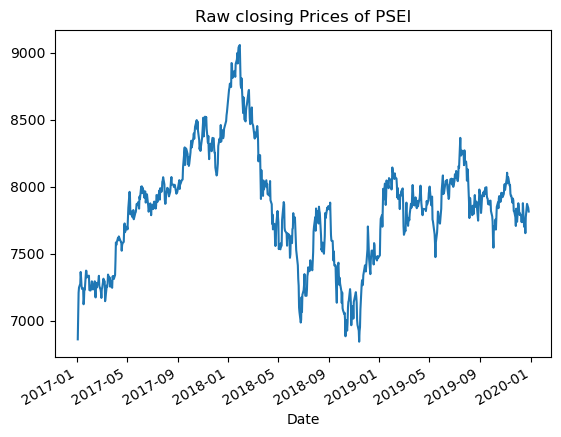

In [3]:
data_loader.visualize_data_raw_returns()

# Visualization of log returns of PSEI (2017-01-03 - 2019-12-27)

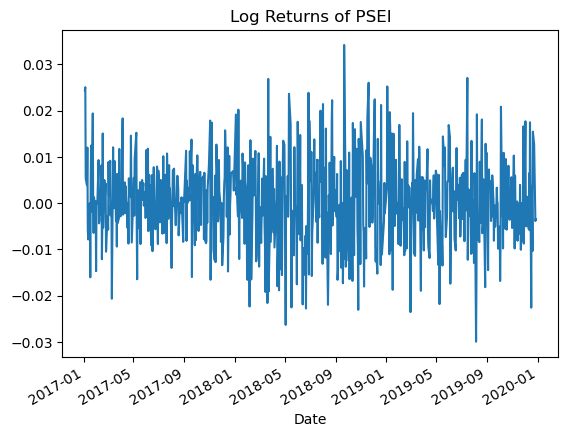

In [4]:
data_loader.visualize_data_log_returns()

### Findings proper
## Visualization preparations

In [5]:
def visualize_data_systems_normalized(
    outcomes : pd.DataFrame
) -> None:
    outcomes["aggregate"][["Rolling_STDEV_Normalized", "STFT_Normalized"]].plot()
    plt.title("Normalized Outputs of Rolling STDEV and STFT")
    plt.xlabel("Time")
    plt.ylabel("Normalized Value")
    plt.legend()
    plt.show()

def visualize_confusion_matrix(
    confusion_matrix : pd.DataFrame
) -> None:
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix,
        display_labels=["Low", "Medium", "High"]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix of Regime Classifications")
    plt.xlabel("STFT Regime")
    plt.ylabel("Rolling STDEV Regime")
    plt.show()

def visualize_individual_systems(
    system_outputs : pd.DataFrame,
    thresholds : pd.DataFrame
) -> None:
    system_outputs.plot()
    plt.axhline(y=thresholds["Low"], color='green', linestyle='--', label='Low Threshold')
    plt.axhline(y=thresholds["High"], color='red', linestyle='--', label='High Threshold')
    plt.title("Individual System Outputs with Thresholds")
    plt.xlabel("Time")
    plt.ylabel("Output Value")
    plt.legend()
    plt.show()

## 64 days rolling window
- Both systems performed almost the same analytically
- Rolling Standard Deviation has many micromovements due to being more concerned with distance to  mean of the rolling window
- STFT is smoother visually and has successfully reduced short term noise to discern the real closing prices signals

In [6]:
comparator_engine = ComparatorEngine(treated_data)
outcomes = comparator_engine.trial_single_window(interval=64)

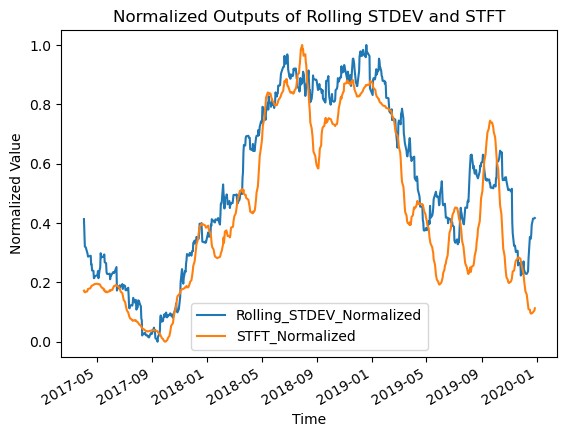

In [7]:
visualize_data_systems_normalized(outcomes)

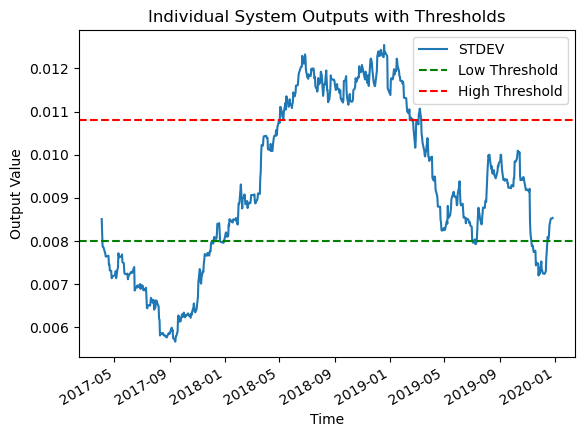

In [8]:
visualize_individual_systems(outcomes["aggregate"]["STDEV"], outcomes["thresholds"]["STDEV"])

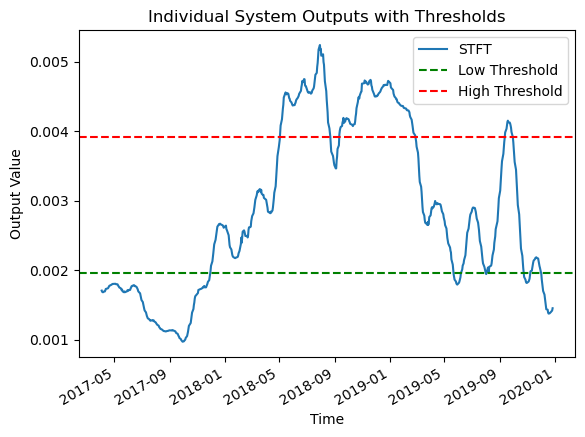

In [9]:
visualize_individual_systems(outcomes["aggregate"]["STFT"], outcomes["thresholds"]["STFT"])

In [10]:
(outcomes["cohen_kappa"], outcomes["pearson_correlation"], outcomes["pearson_p_value"])

(0.7816393442622951,
 np.float64(0.9308682033623458),
 np.float64(1.4609033148661047e-292))

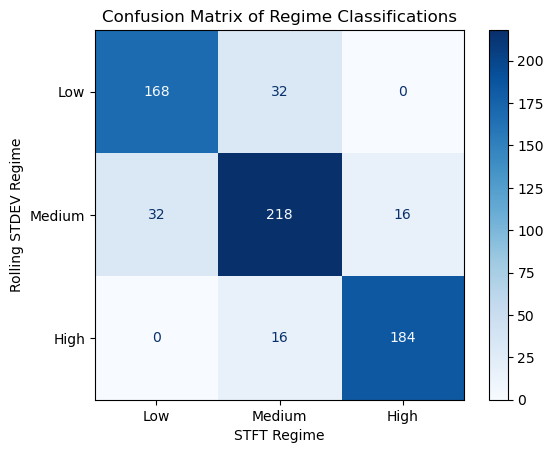

In [11]:
visualize_confusion_matrix(outcomes["confusion_matrix"])

## 32 day Rolling Window
- Both systems performed almost the same analytically with noted increase on disagreements
- Rolling Standard Deviation has many micromovements due to being more concerned with distance to  mean of the rolling window with the short term movements building up to a general trend in the long term
- STFT is smoother visually and has successfully reduced short term noise to discern the real closing prices signals a increased larger "jumps" are noted

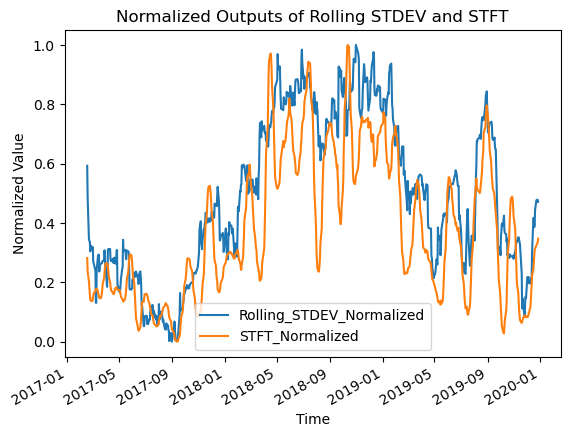

In [12]:
outcomes = comparator_engine.trial_single_window(interval=32)
visualize_data_systems_normalized(outcomes)

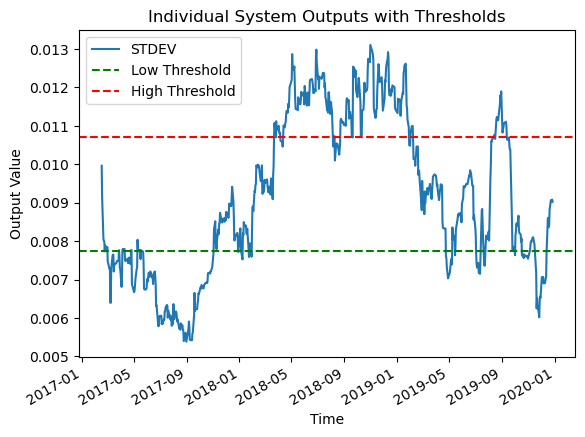

In [13]:
visualize_individual_systems(outcomes["aggregate"]["STDEV"], outcomes["thresholds"]["STDEV"])

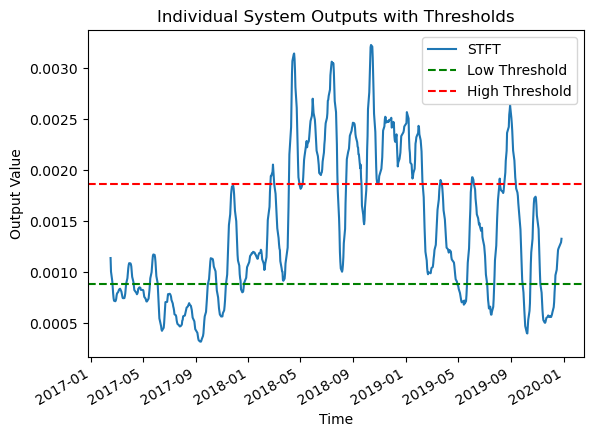

In [14]:
visualize_individual_systems(outcomes["aggregate"]["STFT"], outcomes["thresholds"]["STFT"])

In [15]:
(outcomes["cohen_kappa"], outcomes["pearson_correlation"], outcomes["pearson_p_value"])

(0.648526669153301,
 np.float64(0.8528381100263377),
 np.float64(1.4112544500705062e-198))

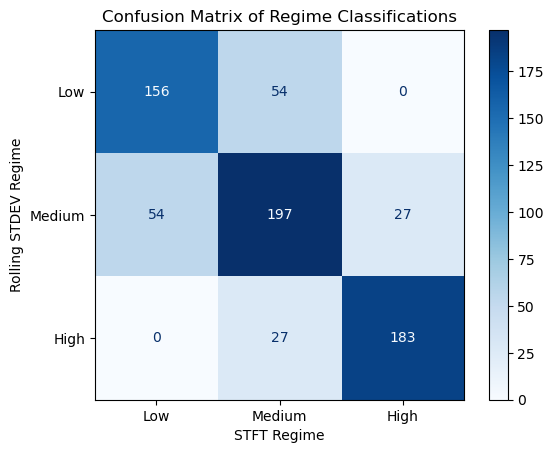

In [16]:
visualize_confusion_matrix(outcomes["confusion_matrix"])

## 16 day Rolling Window
- Both systems performed almost the same analytically with more observable disagreements
- Rolling Standard Deviation has more fluctuations big and large that has sharp movements but the buildups on its tips could be noted as a indication that the curren market volatility regime at that time is changing in its momentum
- STFT has a drastic jigsaw movements and has generally been more incomprehensible than rolling standard deviation at such a narrow rolling window

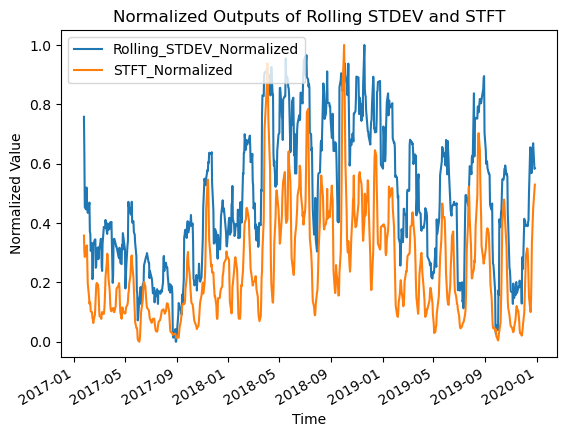

In [17]:
outcomes = comparator_engine.trial_single_window(interval=16)
visualize_data_systems_normalized(outcomes)

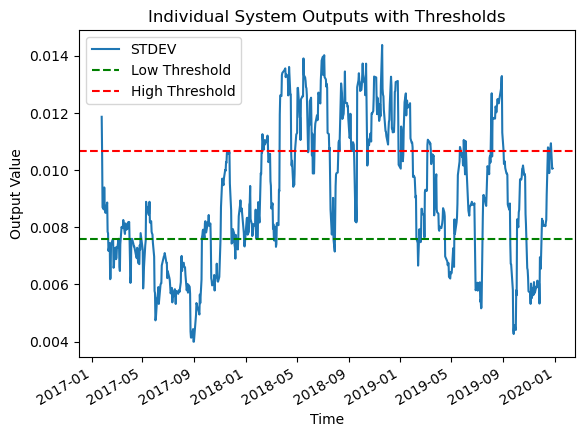

In [18]:
visualize_individual_systems(outcomes["aggregate"]["STDEV"], outcomes["thresholds"]["STDEV"])

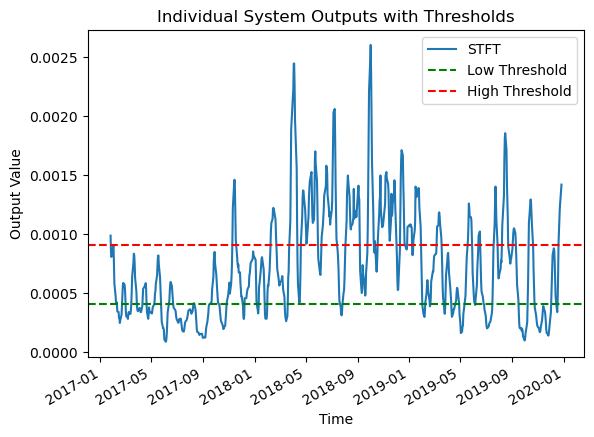

In [19]:
visualize_individual_systems(outcomes["aggregate"]["STFT"], outcomes["thresholds"]["STFT"])

In [20]:
(outcomes["cohen_kappa"], outcomes["pearson_correlation"], outcomes["pearson_p_value"])

(0.5755154455304273,
 np.float64(0.8072397868737419),
 np.float64(3.404328307344355e-165))

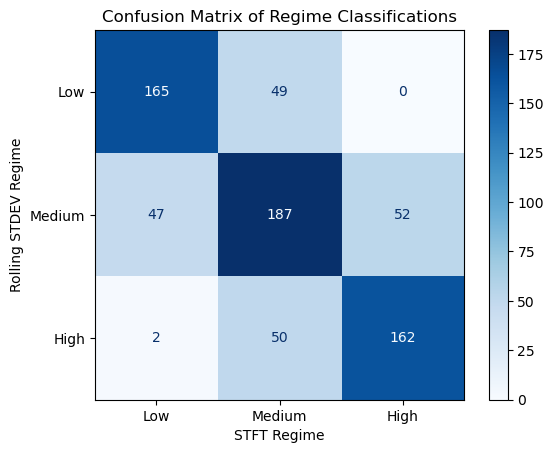

In [21]:
visualize_confusion_matrix(outcomes["confusion_matrix"])